In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import chi2_contingency


In [4]:
def load_and_validate_data(file_path):
    try:
        data = pd.read_csv(file_path)
        print("Data loaded successfully.")
        print("Data summary:")
        print(data.info())
        print("\nMissing values:")
        print(data.isnull().sum())
        required_columns = ['name','price','size','description']        
        missing_cols = [col for col in required_columns if col not in data.columns]
        if missing_cols:
            raise ValueError(f"Missing columns: {missing_cols}")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
df = load_and_validate_data('products_asos.csv')

Data loaded successfully.
Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        30827 non-null  object 
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB
None

Missing values:
url            18
name           18
size           18
category       18
price          18
color          18
sku            18
description    18
images         18
dtype: int64


In [5]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
# checking price range 
print(f"Price range before cleaning : {df['price'].min()} - {df['price'].max()}")
# Removing outliers based on price
initial_count = len(df)
df = df.dropna(subset=['price'])
print(f"Dropped {initial_count - len(df)} rows with invalid price.")


Price range before cleaning : 4.5 - 550.0
Dropped 12467 rows with invalid price.


In [7]:
#cleaning whitespaces and special characters from name and description columns
df['name'] = df['name'].astype(str).str.strip().replace(r'^\s+$', ' ', regex=True)
df['description'] = df['description'].astype(str).str.strip().replace(r'^\s+$', ' ', regex=True)
#filling empty strings in name and description 
df['name'] = df['name'].replace('', 'Unknown')
df['description'] = df['description'].replace('', 'No description')

In [11]:
#creating brand column
known_brands = {
    'ASOS', 'ASOS DESIGN', 'ASOS EDITION', 
    'Topshop', 'Topman', 
    'Nike', 'adidas', 'New Balance', 'Puma', 'Reebok',
    'Stradivarius', 'Zara', 'Pull&Bear', 'Bershka',
    'JDY', 'Jaded London', 'Collusion', 'Collusion x',
    'Levi''s', 'Levis', 'Calvin Klein', 'CK'
}

def extract_brand(name):
    """Improved brand extraction with better matching"""
    if not name or name == 'None':
        return 'Unknown'
    
    name_clean = name.strip().lower()
    
    # Check for known brand patterns at the start
    for brand in known_brands:
        brand_lower = brand.lower()
        if name_clean.startswith(brand_lower) or name_clean.startswith(brand_lower + ' '):
            return brand
    
    # Default: first word (single) or first two words
    words = name.split()
    if len(words) == 1:
        return words[0].capitalize()
    else:
        # Check if first two words look like a brand
        return ' '.join(words[:2]).capitalize()

df['brand'] = df['name'].apply(extract_brand)

df.head(5)


,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius


number of unique brands: 1957
Top 10 brands:
brand
ASOS              4842
Topshop           1136
River island       474
New look           469
Miss selfridge     427
adidas             395
Collusion          383
Stradivarius       345
Bershka            344
Vero moda          327
Name: count, dtype: int64


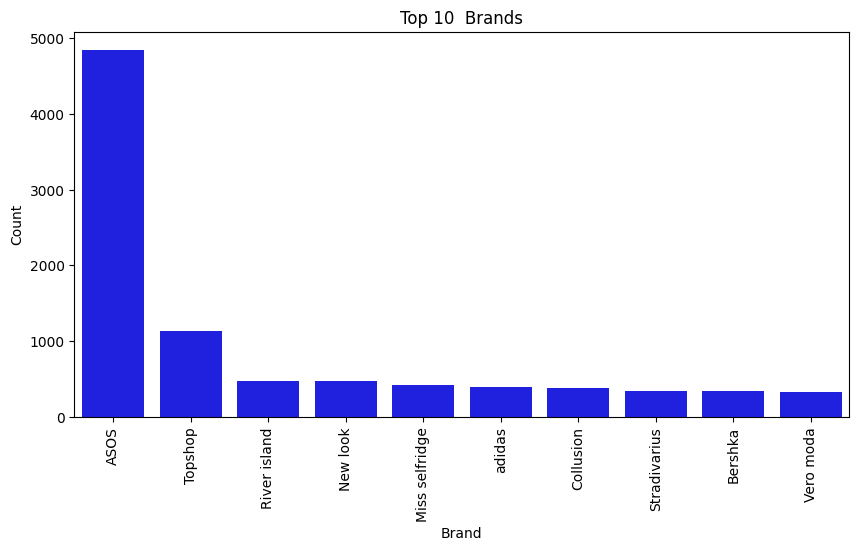

In [12]:
# counting the number of times each brand appears in the dataset
brand_counts = df['brand'].value_counts()
print(f"number of unique brands: {len(brand_counts)}")
# getting the top 10 brands
top_10_brands = brand_counts.head(10)
print("Top 10 brands:")
print(top_10_brands)
# plotting the top 10 brands in blue color
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_brands.index, y=top_10_brands.values, color='blue')
plt.title('Top 10  Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

In [15]:
#checking and handling duplicate entries
duplicates = df.duplicated(subset=['name', 'price', 'size', 'description'], keep=False)
dup_count = duplicates.sum()
print(f"Number of duplicate entries: {dup_count}")

df = df.drop_duplicates(subset=['name', 'price', 'size'], keep='first')
print(f"Number of entries after removing duplicates: {len(df)}")

Number of duplicate entries: 806
Number of entries after removing duplicates: 17848


In [ ]:
# analyzing stocks
def check_stock_status(size_value):
    if not size_value or size_value == 'None':
        return 'In stock'  
    
    # Check for various "out of stock" patterns
    oos_patterns = [
        r'\bOut of stock\b',
        r'\boos\b',
        r'out\s*of\s*stock',
        r'\(out of stock\)',
        r'\[out of stock\]',
    ]
    
    for pattern in oos_patterns:
        if re.search(pattern, str(size_value), re.IGNORECASE):
            return 'Out of stock'
    
    return 'In stock'

df['stock'] = df.loc[:, 'size'].apply(check_stock_status)

# Verify stock distribution
stock_counts = df.loc[:, 'stock'].value_counts()
print(f"\nStock Status:\n{stock_counts}")


Stock Status:
stock
Out of stock    9638
In stock        8210
Name: count, dtype: int64


C:\Users\JA 12\AppData\Local\Temp\ipykernel_9988\284823908.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stock'] = df.loc[:, 'size'].apply(check_stock_status)


In [18]:
missing_summary = df.isnull().sum()
print(f"\nMissing values summary:\n{missing_summary[missing_summary > 0]}")
#drop rows with missing values 
df = df.dropna(subset=['brand'])
print(f"final dataset size after cleaning: {len(df)} rows")



Missing values summary:
Series([], dtype: int64)
final dataset size after cleaning: 17848 rows


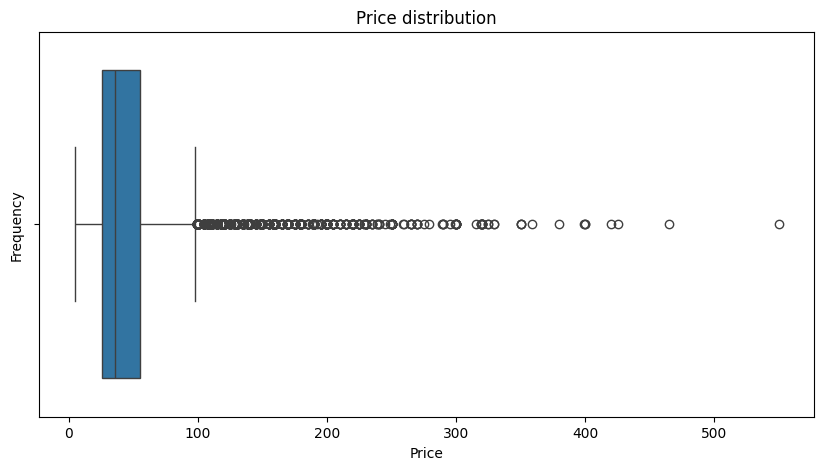

In [20]:
#plotting price distribution
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


C:\Users\JA 12\AppData\Local\Temp\ipykernel_9988\486475947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stock", y="price", data=df, palette="Set2")


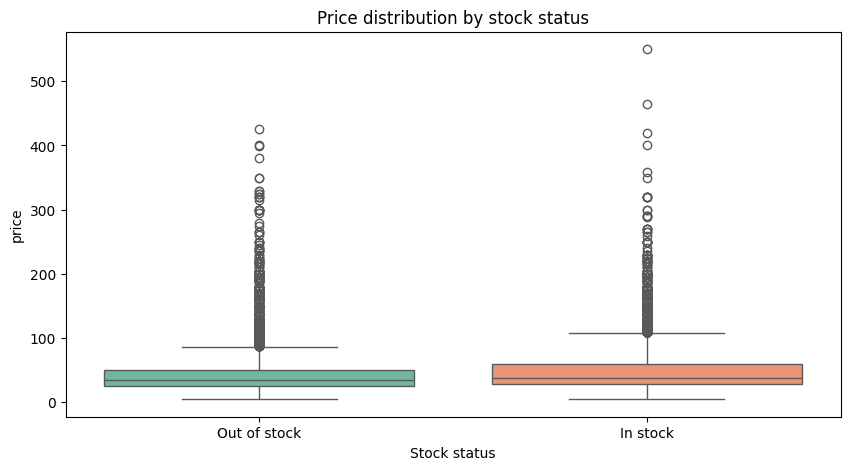

In [19]:
# plotting price distribution by stock status
plt.figure(figsize=(10,5))
sns.boxplot(x="stock", y="price", data=df, palette="Set2")
plt.title('Price distribution by stock status')
plt.xlabel('Stock status')
plt.ylabel('price')
plt.show()

In [21]:
# Brand with most out of stock products
out_of_stock_brands = df[df['stock'] == 'Out of stock'].groupby('brand').size().sort_values(ascending=False)
print("\nBrands with most out of stock products:")
print(out_of_stock_brands.head(10))


Brands with most out of stock products:
brand
ASOS              2641
Topshop            577
New look           334
River island       261
Miss selfridge     215
adidas             212
Stradivarius       212
Vero moda          209
Bershka            203
Collusion          176
dtype: int64


In [22]:
# average price by bands
average_price_by_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False)
print("\nBrands with most expensive products on average:")
print(average_price_by_brand.head(10))


Brands with most expensive products on average:
brand
Napapijri skidoo       420.000000
Allsaints benyon       359.000000
Roxy peak              350.000000
Allsaints caden        329.000000
Allsaints elora        319.000000
Allsaints balfern      319.000000
Hugo polyester         319.000000
Napapijri x            316.666667
Fiorucci balconette    275.000000
Napapijri a-harness    265.000000
Name: price, dtype: float64


In [23]:
# chi-square test for association between brand and stock status
top_10_brands = df['brand'].value_counts().head(10).index.tolist()
df_top = df[df['brand'].isin(top_10_brands)]
crosstab = pd.crosstab(df_top['brand'], df_top['stock'])

if crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"\nChi-square test results:")
    print(f"Chi-square statistic: {chi2:.2f}")
    print(f"p-value: {p:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"Statistically significant: {'Yes' if p < 0.05 else 'No'}")


Chi-square test results:
Chi-square statistic: 116.93
p-value: 0.0000
Degrees of freedom: 9
Statistically significant: Yes


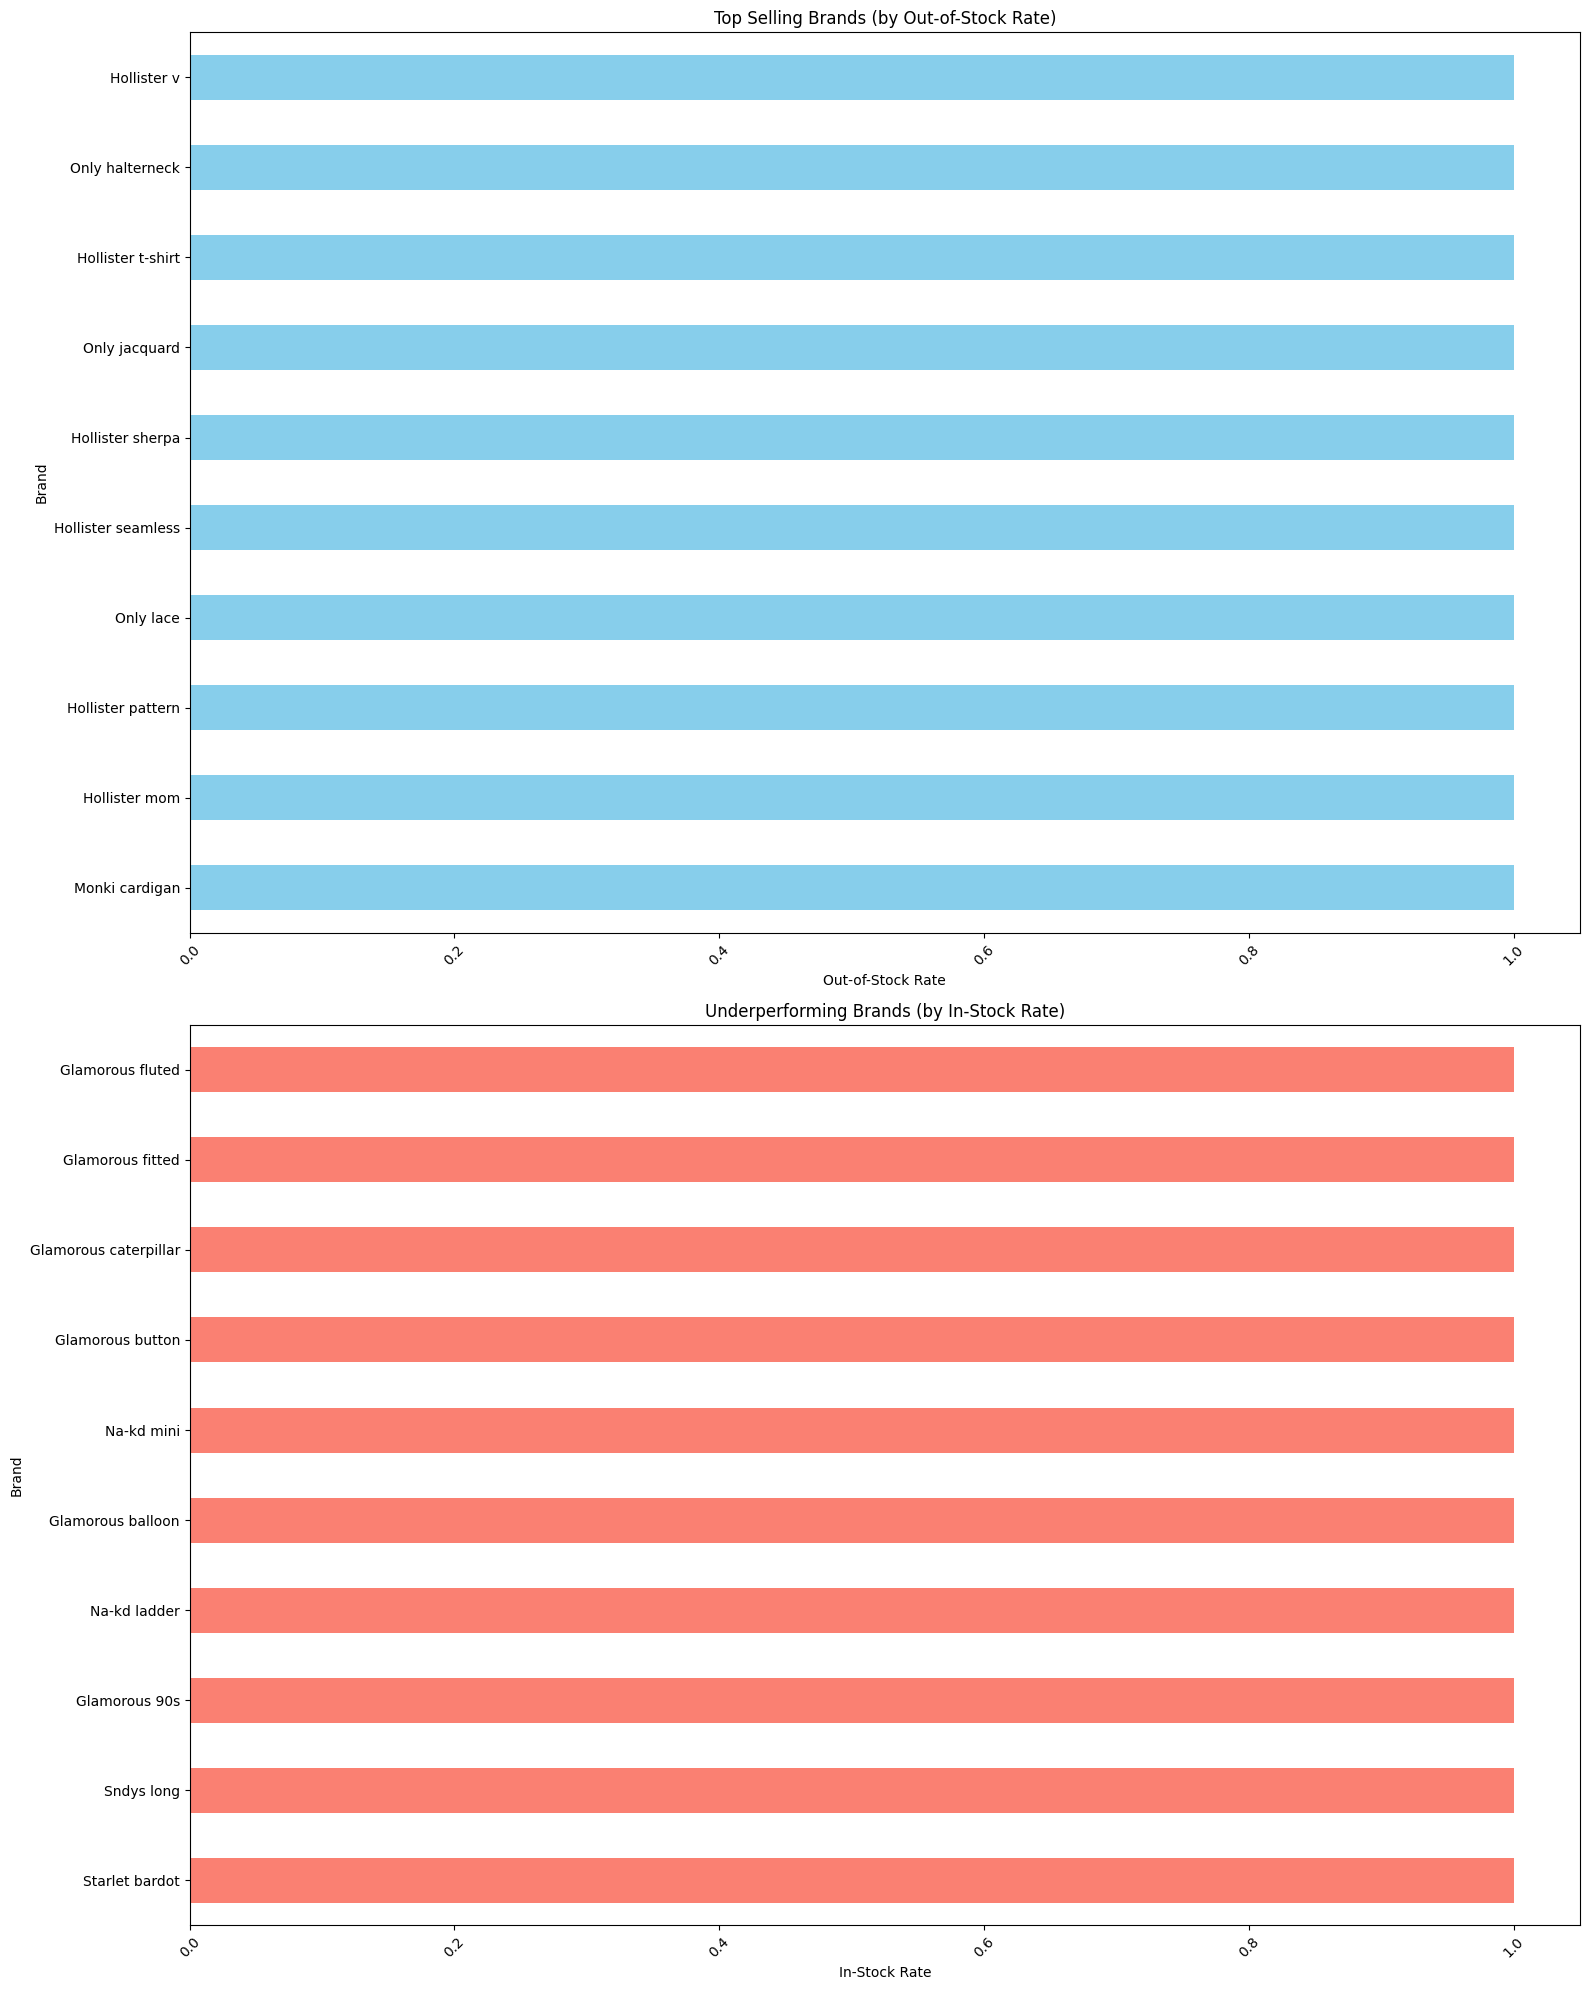

In [24]:
# Brand stock ratio visualization
brand_stock_ratio = df.groupby('brand')['stock'].value_counts(normalize=True).unstack(fill_value=0)
brand_stock_ratio['out_of_stock_rate'] = brand_stock_ratio.get('Out of stock', 0)
brand_stock_ratio['in_stock_rate'] = brand_stock_ratio.get('In stock', 0)

top_sellers = brand_stock_ratio.sort_values(by='out_of_stock_rate', ascending=False).head(10)
underperformers = brand_stock_ratio.sort_values(by='in_stock_rate', ascending=False).head(10)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 20))

top_sellers['out_of_stock_rate'].plot(
    kind='barh',
    ax=axes[0],
    color='skyblue',
    title='Top Selling Brands (by Out-of-Stock Rate)'
)
axes[0].set_xlabel('Out-of-Stock Rate')
axes[0].set_ylabel('Brand')
axes[0].tick_params(axis='x', labelrotation=45)

underperformers['in_stock_rate'].plot(
    kind='barh',
    ax=axes[1],
    color='salmon',
    title='Underperforming Brands (by In-Stock Rate)'
)
axes[1].set_xlabel('In-Stock Rate')
axes[1].set_ylabel('Brand')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

In [25]:
df_in_stock = df[df['stock'] == 'In stock'].copy()
df_in_stock.to_csv('products_asos_in_stock.csv', index=False)

In [26]:
df.to_csv('products_asos_cleaned.csv', index=False)

print("\n✓ Data cleaning complete!")
print(f"  - In-stock products saved: products_asos_in_stock.csv ({len(df_in_stock)} products)")
print(f"  - Full cleaned dataset saved: products_asos_cleaned.csv ({len(df)} products)")


✓ Data cleaning complete!
  - In-stock products saved: products_asos_in_stock.csv (8210 products)
  - Full cleaned dataset saved: products_asos_cleaned.csv (17848 products)
